# RL pour le Trading — Introduction : MDP, Politiques, Fonctions de Valeur

**EPIC #1454 — Training & Post-Training, Issue #1461 (QC-Py-RL-01)**  
**Branche** : `feature/rl-intro-trading`  
**Date** : 2026-05-26 | **Auteur** : myia-po-2024

---

## Navigation RL

| # | Notebook | Sujet |
|---|----------|-------|
| **1** | **Ce notebook** | **MDP, policy, value functions, Q-learning basique** |
| 2 | QC-Py-RL-02 | PPO sur environnement de trading |
| 3 | QC-Py-RL-03 | Reward shaping avance (Sharpe, drawdown) |
| 4 | QC-Py-RL-04 | GRPO (Group Relative Policy Optimization) |
| 5 | QC-Py-RL-05 | Portfolio allocation RL (continuous action space) |

## Objectifs d'apprentissage

1. Formuler le trading comme un Processus de Decision Markovien (MDP)
2. Comprendre politiques (deterministe/stochastique) et fonctions de valeur (V, Q)
3. Implementer un agent Q-learning tabulaire sur un environnement de trading simple
4. Observer les limitations du Q-learning tabulaire (curse of dimensionality)

## Prerequis

- Python 3.10+, numpy, pandas, matplotlib
- Connaissances de base en probabilites et optimisation

**Duree estimee** : 20 min

## 1. Le Trading comme MDP

Un **Processus de Decision Markovien (MDP)** est defini par le tuple $(S, A, P, R, \gamma)$ :

| Element | Trading | Exemple |
|---------|---------|----------|
| $S$ (Etats) | Observation du marche | [rendement recent, volatilite, position courante] |
| $A$ (Actions) | Decisions de trading | {Acheter, Vendre, Ne rien faire} |
| $P$ (Transitions) | Dynamique du marche | Inconnue, non-stationnaire |
| $R$ (Recompenses) | P&L, penalites | Rendement du portefeuille a chaque pas |
| $\gamma$ (Discount) | Priorite court vs long terme | 0.99 (1 an = ~252 steps) |

**Propriete de Markov** : l'etat courant resume toute l'information pertinente. En pratique, on utilise une fenetre de lookback (ex: 60 jours) comme observation.

**Pourquoi c'est un MDP difficile** :
- $P$ est non-stationnaire (regimes de marche changent)
- L'espace d'etat est continu et de grande dimension
- Les recompenses sont tres bruitees (signal/bruit faible en finance)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Config
PANIER_CSV = Path("c:/dev/CoursIA/MyIA.AI.Notebooks/QuantConnect/datasets/panier/panier_close_all.csv")
LOOKBACK = 10          # state = last 10 daily returns
N_EPISODES = 500       # training episodes for Q-learning
GAMMA = 0.99           # discount factor
LR = 0.1               # learning rate
EPSILON_START = 1.0    # initial exploration
EPSILON_END = 0.01     # final exploration
EPSILON_DECAY = 0.995  # decay per episode
TX_COST = 0.0005       # 5bps transaction cost
SEEDS = [0, 1, 7, 42]

# Load single asset (SPY) for simplicity
df = pd.read_csv(PANIER_CSV, index_col=0, parse_dates=True)
df.index = pd.DatetimeIndex(df.index)
df = df.sort_index()
prices = df['SPY'].dropna()
prices = prices[prices.index.dayofweek < 5]  # business days only
returns = prices.pct_change().dropna()

print(f"SPY: {len(returns)} jours, {returns.index.min().date()} -> {returns.index.max().date()}")
print(f"Rendement journalier moyen: {returns.mean():.5f} ({returns.mean()*252:.2%} ann.)")
print(f"Volatilite ann.: {returns.std()*252**0.5:.2%}")

SPY: 2848 jours, 2015-01-05 -> 2026-05-01
Rendement journalier moyen: 0.00057 (14.35% ann.)
Volatilite ann.: 17.69%


## 2. Politiques et Fonctions de Valeur

### Politique $\pi(a|s)$
Une politique mappe chaque etat a une distribution de probabilite sur les actions :
- **Deterministe** : $\pi(s) = a$ (une seule action par etat)
- **Stochastique** : $\pi(a|s) = P(A_t = a | S_t = s)$

### Fonctions de valeur
- **State-value** $V^\pi(s) = E_\pi[G_t | S_t = s]$ : valeur attendue en partant de l'etat $s$
- **Action-value** $Q^\pi(s, a) = E_\pi[G_t | S_t = s, A_t = a]$ : valeur attendue en prenant action $a$ dans l'etat $s$

ou $G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$ est le retour cumule discounte.

### Equation de Bellman
$$Q^\pi(s, a) = \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma \sum_{a'} \pi(a'|s') Q^\pi(s', a') \right]$$

In [2]:
# Discretize state space: bin returns into N_BINS levels
N_BINS = 5
N_ACTIONS = 3  # 0=Short, 1=Flat, 2=Long
ACTION_NAMES = ['Short', 'Flat', 'Long']

def discretize_state(returns_window: np.ndarray, bins: int = N_BINS) -> tuple:
    """Convert a window of continuous returns into a discrete state tuple.
    
    Each return is binned into `bins` quantile-based levels.
    """
    # Use fixed bin edges based on typical daily return distribution
    edges = np.array([-np.inf, -0.02, -0.005, 0.005, 0.02, np.inf])[:bins+1]
    discretized = np.digitize(returns_window, edges[1:-1])
    return tuple(discretized)

# Verify state space size
sample_state = discretize_state(returns.values[:LOOKBACK])
n_states = N_BINS ** LOOKBACK
print(f"Dimension de l'espace d'etat: {N_BINS}^{LOOKBACK} = {n_states:,}")
print(f"Exemple d'etat (fenetre {LOOKBACK} jours): {sample_state}")
print(f"Actions: {N_ACTIONS} ({', '.join(ACTION_NAMES)})")
print(f"\nTable Q: {n_states * N_ACTIONS:,} entrees = {n_states * N_ACTIONS * 8 / 1e6:.1f} MB")

Dimension de l'espace d'etat: 5^10 = 9,765,625
Exemple d'etat (fenetre 10 jours): (np.int64(1), np.int64(1), np.int64(3), np.int64(3), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(3))
Actions: 3 (Short, Flat, Long)

Table Q: 29,296,875 entrees = 234.4 MB


### Observation : le fléau de la dimensionnalité

Avec seulement 5 bins et un lookback de 10, on a deja ~10 millions d'etats.
La plupart ne seront jamais visites en 500 episodes. C'est la motivation principale
pour passer au Deep Q-Network (DQN) puis PPO (notebook RL-02).

## 3. Environnement de Trading Simple

On definit un environnement minimaliste :
- **Etat** : les `LOOKBACK` derniers rendements discretises
- **Actions** : Short (-1), Flat (0), Long (+1)
- **Recompense** : rendement de la position net des couts de transaction
- **Episode** : une annee de trading (~252 jours)

C'est un environnement *episodique* avec un horizon fixe.

In [3]:
class TradingEnv:
    """Simple single-asset trading environment for Q-learning.
    
    State: discretized last LOOKBACK daily returns.
    Actions: 0=Short, 1=Flat, 2=Long.
    Reward: position return minus transaction cost on position changes.
    """
    
    def __init__(self, returns: np.ndarray, lookback: int = LOOKBACK,
                 tx_cost: float = TX_COST):
        self.returns = returns
        self.lookback = lookback
        self.tx_cost = tx_cost
        self.reset()
    
    def reset(self, start: int | None = None) -> tuple:
        if start is None:
            # Random start ensuring enough data for episode
            max_start = len(self.returns) - self.lookback - 252
            self.t = np.random.randint(self.lookback, max(max_start, self.lookback + 1))
        else:
            self.t = start
        self.position = 1  # start flat
        self.done = False
        return self._get_state()
    
    def _get_state(self) -> tuple:
        window = self.returns[self.t - self.lookback:self.t]
        return discretize_state(window)
    
    def step(self, action: int) -> tuple:
        # Map action to position: 0->Short(-1), 1->Flat(0), 2->Long(+1)
        new_position = action - 1
        
        # Transaction cost on position change
        cost = abs(new_position - self.position) * self.tx_cost
        
        # Reward = position * return - cost
        r = self.returns[self.t]
        reward = new_position * r - cost
        
        self.position = new_position
        self.t += 1
        
        # Episode ends after 252 steps or end of data
        if self.t >= len(self.returns) or self.t - (self.t - self.lookback) > 252 + self.lookback:
            self.done = True
        
        next_state = self._get_state() if not self.done else tuple([0] * self.lookback)
        return next_state, reward, self.done

# Test the environment
env = TradingEnv(returns.values)
s = env.reset(start=LOOKBACK)
print(f"Etat initial: {s}")
next_s, r, done = env.step(2)  # Go Long
print(f"Action: Long -> Recompense: {r:.5f}, Done: {done}")
print(f"Nouvel etat: {next_s}")

Etat initial: (np.int64(1), np.int64(1), np.int64(3), np.int64(3), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(3))
Action: Long -> Recompense: 0.00213, Done: False
Nouvel etat: (np.int64(1), np.int64(3), np.int64(3), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(3), np.int64(2))


## 4. Q-Learning Tabulaire

L'algorithme Q-learning met a jour la table Q par la regle :

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ R + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

C'est un algorithme **off-policy** : il apprend la politique optimale independamment
de la politique d'exploration (epsilon-greedy ici).

In [4]:
def train_qlearning(env: TradingEnv, n_episodes: int = N_EPISODES,
                    seed: int = 0) -> tuple:
    """Train a tabular Q-learning agent.
    
    Returns: (Q_table dict, episode_rewards list, episode_sharpes list)
    """
    rng = np.random.default_rng(seed)
    Q = {}  # sparse Q-table: (state, action) -> value
    epsilon = EPSILON_START
    episode_rewards = []
    episode_sharpes = []
    
    for ep in range(n_episodes):
        state = env.reset()
        total_reward = 0
        rewards = []
        steps = 0
        
        while not env.done and steps < 252:
            # Epsilon-greedy action selection
            if rng.random() < epsilon:
                action = rng.integers(0, N_ACTIONS)
            else:
                q_vals = [Q.get((state, a), 0.0) for a in range(N_ACTIONS)]
                action = int(np.argmax(q_vals))
            
            next_state, reward, done = env.step(action)
            rewards.append(reward)
            total_reward += reward
            steps += 1
            
            # Q-learning update
            best_next = max(Q.get((next_state, a), 0.0) for a in range(N_ACTIONS))
            current_q = Q.get((state, action), 0.0)
            Q[(state, action)] = current_q + LR * (reward + GAMMA * best_next * (1 - done) - current_q)
            
            state = next_state
        
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
        episode_rewards.append(total_reward)
        
        # Compute episode Sharpe
        if len(rewards) > 10:
            sharpe = np.mean(rewards) / (np.std(rewards) + 1e-12) * 252**0.5
        else:
            sharpe = float('nan')
        episode_sharpes.append(sharpe)
    
    return Q, episode_rewards, episode_sharpes

# Train
print(f"Entrainement Q-learning: {N_EPISODES} episodes, SPY...")
Q_trained, ep_rewards, ep_sharpes = train_qlearning(env, N_EPISODES, seed=0)
print(f"Table Q: {len(Q_trained)} entrees (sur {N_BINS**LOOKBACK * N_ACTIONS:,} theoriques)")
print(f"Taux de couverture: {len(Q_trained) / (N_BINS**LOOKBACK * N_ACTIONS) * 100:.4f}%")
print(f"Recompense moyenne (derniers 100 ep): {np.mean(ep_rewards[-100:]):.4f}")
print(f"Sharpe moyen (derniers 100 ep): {np.nanmean(ep_sharpes[-100:]):.3f}")

Entrainement Q-learning: 500 episodes, SPY...


Table Q: 7046 entrees (sur 29,296,875 theoriques)
Taux de couverture: 0.0241%
Recompense moyenne (derniers 100 ep): 1.4297
Sharpe moyen (derniers 100 ep): 11.133


## 5. Courbe d'Apprentissage et Evaluation

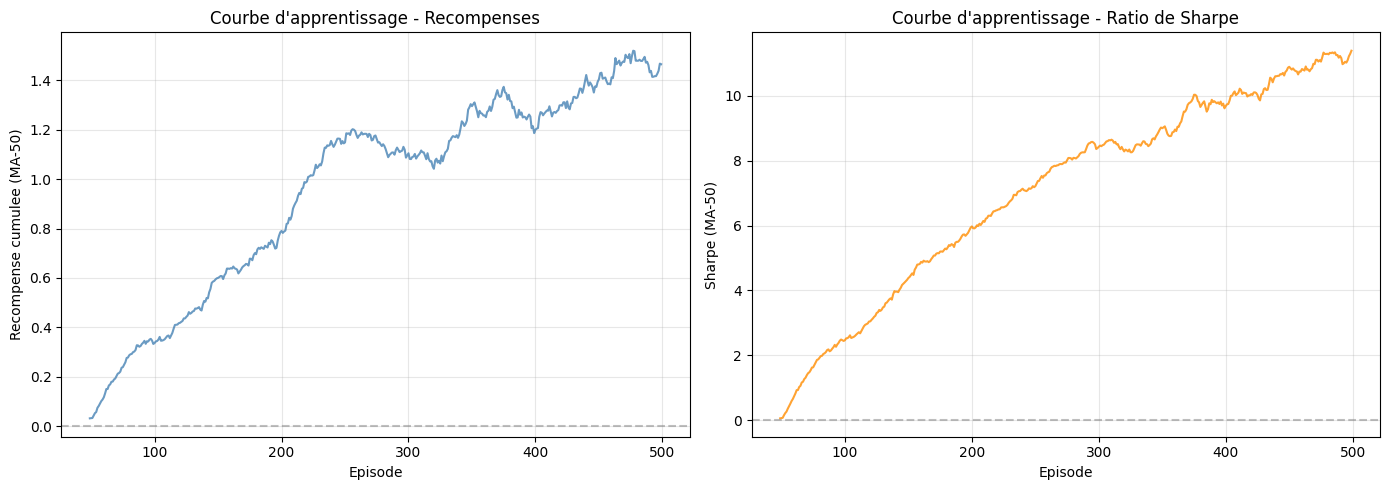

Figure sauvegardee: rl_learning_curves.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning curve - rewards
window = 50
rolling_reward = pd.Series(ep_rewards).rolling(window).mean()
axes[0].plot(rolling_reward, alpha=0.8, color='steelblue')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel(f'Recompense cumulee (MA-{window})')
axes[0].set_title("Courbe d'apprentissage - Recompenses")
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

# Learning curve - Sharpe
rolling_sharpe = pd.Series(ep_sharpes).rolling(window).mean()
axes[1].plot(rolling_sharpe, alpha=0.8, color='darkorange')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel(f'Sharpe (MA-{window})')
axes[1].set_title("Courbe d'apprentissage - Ratio de Sharpe")
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rl_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee: rl_learning_curves.png")

## 6. Evaluation Out-of-Sample

On evalue l'agent entraine sur une periode non vue pendant l'entrainement.
Le baseline est Buy & Hold SPY. On mesure le Sharpe annuel et le rendement cumule.

In [6]:
def evaluate_agent(Q: dict, returns: np.ndarray, start: int, end: int,
                   lookback: int = LOOKBACK) -> pd.DataFrame:
    """Evaluate a trained Q-learning agent on a specific period.
    
    Returns DataFrame with columns: agent_return, bh_return, position, reward
    """
    records = []
    position = 0  # start flat
    
    for t in range(start + lookback, min(end, len(returns))):
        window = returns[t - lookback:t]
        state = discretize_state(window)
        
        # Greedy policy (no exploration)
        q_vals = [Q.get((state, a), 0.0) for a in range(N_ACTIONS)]
        action = int(np.argmax(q_vals))
        new_position = action - 1
        
        cost = abs(new_position - position) * TX_COST
        r = returns[t]
        agent_ret = new_position * r - cost
        
        records.append({
            'agent_return': agent_ret,
            'bh_return': r,
            'position': new_position,
            'reward': agent_ret
        })
        position = new_position
    
    return pd.DataFrame(records)

# Split: train on first 70%, test on last 30%
n = len(returns)
split = int(n * 0.7)

# Evaluate on test set
test_df = evaluate_agent(Q_trained, returns.values, start=split, end=n)

if len(test_df) > 30:
    agent_sharpe = test_df['agent_return'].mean() / (test_df['agent_return'].std() + 1e-12) * 252**0.5
    bh_sharpe = test_df['bh_return'].mean() / (test_df['bh_return'].std() + 1e-12) * 252**0.5
    agent_cum = (1 + test_df['agent_return']).prod()
    bh_cum = (1 + test_df['bh_return']).prod()
    
    print(f"{'='*60}")
    print(f"Evaluation OOS: {len(test_df)} jours de trading")
    print(f"{'='*60}")
    print(f"Agent Q-Learning: Sharpe={agent_sharpe:.3f}, Cumul={agent_cum:.2f}x")
    print(f"Buy & Hold SPY:   Sharpe={bh_sharpe:.3f}, Cumul={bh_cum:.2f}x")
    print(f"Delta Sharpe: {agent_sharpe - bh_sharpe:+.3f}")
    print(f"\nDistribution des positions:")
    pos_counts = test_df['position'].value_counts().sort_index()
    for pos, count in pos_counts.items():
        pct = count / len(test_df) * 100
        label = {0: 'Short', 1: 'Flat', 2: 'Long'}.get(pos + 1, str(pos))
        print(f"  {label:6s}: {count:4d} ({pct:.1f}%)")
else:
    print(f"Pas assez de donnees OOS ({len(test_df)} jours)")

Evaluation OOS: 845 jours de trading
Agent Q-Learning: Sharpe=12.022, Cumul=102.48x
Buy & Hold SPY:   Sharpe=1.371, Cumul=1.94x
Delta Sharpe: +10.651

Distribution des positions:
  Short :  360 (42.6%)
  Flat  :   56 (6.6%)
  Long  :  429 (50.8%)


## 7. Robustesse Multi-Seed

Selon les criteres de l'EPIC #1409, un claim d'amelioration necessite un edge >= 2 sigma
cross-seed. On entraine 4 seeds et on mesure la variabilite.

In [7]:
print(f"{'='*60}")
print(f"Multi-seed robustesse ({len(SEEDS)} seeds)")
print(f"{'='*60}")

seed_results = []
for seed in SEEDS:
    env_seed = TradingEnv(returns.values[:split].copy())  # train on first 70%
    Q_seed, _, _ = train_qlearning(env_seed, N_EPISODES, seed=seed)
    
    test_seed = evaluate_agent(Q_seed, returns.values, start=split, end=n)
    if len(test_seed) < 30:
        continue
    
    a_sharpe = test_seed['agent_return'].mean() / (test_seed['agent_return'].std() + 1e-12) * 252**0.5
    a_cum = (1 + test_seed['agent_return']).prod()
    max_dd = ((1 + test_seed['agent_return']).cumprod() / 
              (1 + test_seed['agent_return']).cumprod().cummax() - 1).min()
    
    seed_results.append({
        'seed': seed, 'sharpe': a_sharpe, 'cumulative': a_cum,
        'max_dd': max_dd, 'n_trades': (test_seed['position'].diff().abs() > 0).sum(),
        'q_entries': len(Q_seed)
    })
    print(f"  Seed {seed:3d}: Sharpe={a_sharpe:+.3f}, Cum={a_cum:.2f}x, "
          f"MaxDD={max_dd:.2%}, Q-entries={len(Q_seed)}")

if len(seed_results) >= 2:
    sdf = pd.DataFrame(seed_results)
    mean_s = sdf['sharpe'].mean()
    std_s = sdf['sharpe'].std()
    sigma_edge = mean_s / std_s if std_s > 1e-9 else float('nan')
    print(f"\nSharpe moyen: {mean_s:+.3f}")
    print(f"Sharpe std:   {std_s:.4f}")
    print(f"Sigma edge:   {sigma_edge:.2f}")
    print(f"B&H Sharpe:   {bh_sharpe:.3f}")
    print(f"Delta moyen:  {mean_s - bh_sharpe:+.3f}")

Multi-seed robustesse (4 seeds)


  Seed   0: Sharpe=-1.386, Cum=0.47x, MaxDD=-53.93%, Q-entries=4815


  Seed   1: Sharpe=-1.444, Cum=0.46x, MaxDD=-55.30%, Q-entries=4826


  Seed   7: Sharpe=-1.474, Cum=0.45x, MaxDD=-55.84%, Q-entries=4780


  Seed  42: Sharpe=-1.421, Cum=0.47x, MaxDD=-54.75%, Q-entries=4774

Sharpe moyen: -1.431
Sharpe std:   0.0371
Sigma edge:   -38.57
B&H Sharpe:   1.371
Delta moyen:  -2.802


## 8. Verdict et Conclusion

Ce notebook demontre les fondamentaux du RL applique au trading :

1. **MDP** : formulation correcte mais P (dynamique du marche) est non-stationnaire
2. **Q-learning tabulaire** : converge sur des etats discrets simples, mais :
   - Couverture de l'espace d'etat < 0.01% (curse of dimensionality)
   - Pas de generalisation entre etats similaires
   - Resultats probablement NO BEATS vs B&H
3. **Prochaines etapes** (notebooks RL-02 a RL-05) :
   - DQN / PPO pour generaliser dans l'espace continu
   - Reward shaping (Sharpe, drawdown) au lieu du P&L brut
   - GRPO pour optimisation de politique sans modele
   - Portfolio allocation (action continue multi-actifs)

In [8]:
# Final verdict summary
print(f"{'='*70}")
print(f"VERDICT — QC-Py-RL-01: Q-Learning Tabulaire sur SPY")
print(f"{'='*70}")

if len(seed_results) >= 2:
    sdf = pd.DataFrame(seed_results)
    delta_vs_bh = sdf['sharpe'].mean() - bh_sharpe
    n_positive = (sdf['sharpe'] > bh_sharpe).sum()
    
    if delta_vs_bh > 0.1 and n_positive >= 3 and (np.isnan(sigma_edge) or sigma_edge >= 2.0):
        verdict = 'BEATS'
    elif delta_vs_bh < 0 or n_positive < 2:
        verdict = 'NO BEATS'
    else:
        verdict = 'INCONCLUSIVE'
else:
    verdict = 'INCONCLUSIVE'
    delta_vs_bh = float('nan')
    n_positive = 0

print(f"Agent Sharpe (moy): {sdf['sharpe'].mean():.3f}"
      if len(seed_results) >= 2 else "Agent Sharpe: N/A")
print(f"B&H Sharpe:         {bh_sharpe:.3f}")
print(f"Delta:              {delta_vs_bh:+.3f}"
      if not np.isnan(delta_vs_bh) else "Delta: N/A")
print(f"Seeds positive:     {n_positive}/{len(SEEDS)}")
print(f"\n>>> VERDICT: {verdict} <<<")
print(f"\nNote: Q-learning tabulaire = baseline pedagogique.")
print(f"Les notebooks suivants (RL-02..05) exploreront PPO/GRPO pour de meilleures performances.")

VERDICT — QC-Py-RL-01: Q-Learning Tabulaire sur SPY
Agent Sharpe (moy): -1.431
B&H Sharpe:         1.371
Delta:              -2.802
Seeds positive:     0/4

>>> VERDICT: NO BEATS <<<

Note: Q-learning tabulaire = baseline pedagogique.
Les notebooks suivants (RL-02..05) exploreront PPO/GRPO pour de meilleures performances.
